# Loyalty Program — Value-Risk Matrix

**วัตถุประสงค์:** ระบุลูกค้าที่เสี่ยง churn และมีมูลค่าสูง เพื่อสร้าง Loyalty Program ที่ตรงใจ

**Prerequisite:** รัน `prediction_stacking.ipynb` ก่อน → ได้ไฟล์ `predictions.csv`

## 1. Import & Load Predictions

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/csv', exist_ok=True)

sns.set_theme(style='whitegrid')

df = pd.read_csv('outputs/csv/predictions.csv')

print(f'Loaded: {df.shape}')display(df.head())

print(f'Churn rate (actual): {df["Churn"].mean():.2%}')print(f'Avg predicted prob : {df["Churn_Prob"].mean():.3f}')

Loaded: (5630, 16)
Churn rate (actual): 16.84%
Avg predicted prob : 0.179


,CustomerID,Churn,CashbackAmount,Tenure,OrderCount,DaySinceLastOrder,Complain,SatisfactionScore,CouponUsed,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,Churn_Prob,Churn_Pred
0,50001,1,160,4.0,1.0,5.0,1,2,1.0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single,0.9816,1
1,50002,1,121,9.0,1.0,0.0,1,3,0.0,Phone,UPI,Male,Mobile,Single,0.9685,1
2,50003,1,120,9.0,1.0,3.0,1,3,0.0,Phone,Debit Card,Male,Mobile,Single,0.9791,1
3,50004,1,134,0.0,1.0,3.0,0,5,0.0,Phone,Debit Card,Male,Laptop & Accessory,Single,0.9674,1
4,50005,1,130,0.0,1.0,3.0,0,5,1.0,Phone,CC,Male,Mobile,Single,0.9803,1


## 2. EDA — Customer Value & Loyalty Patterns

วิเคราะห์ว่า CashbackAmount (มูลค่าลูกค้า) และ Tenure (ความภักดี) กระจายตัวอย่างไร และสัมพันธ์กับ Churn อย่างไร

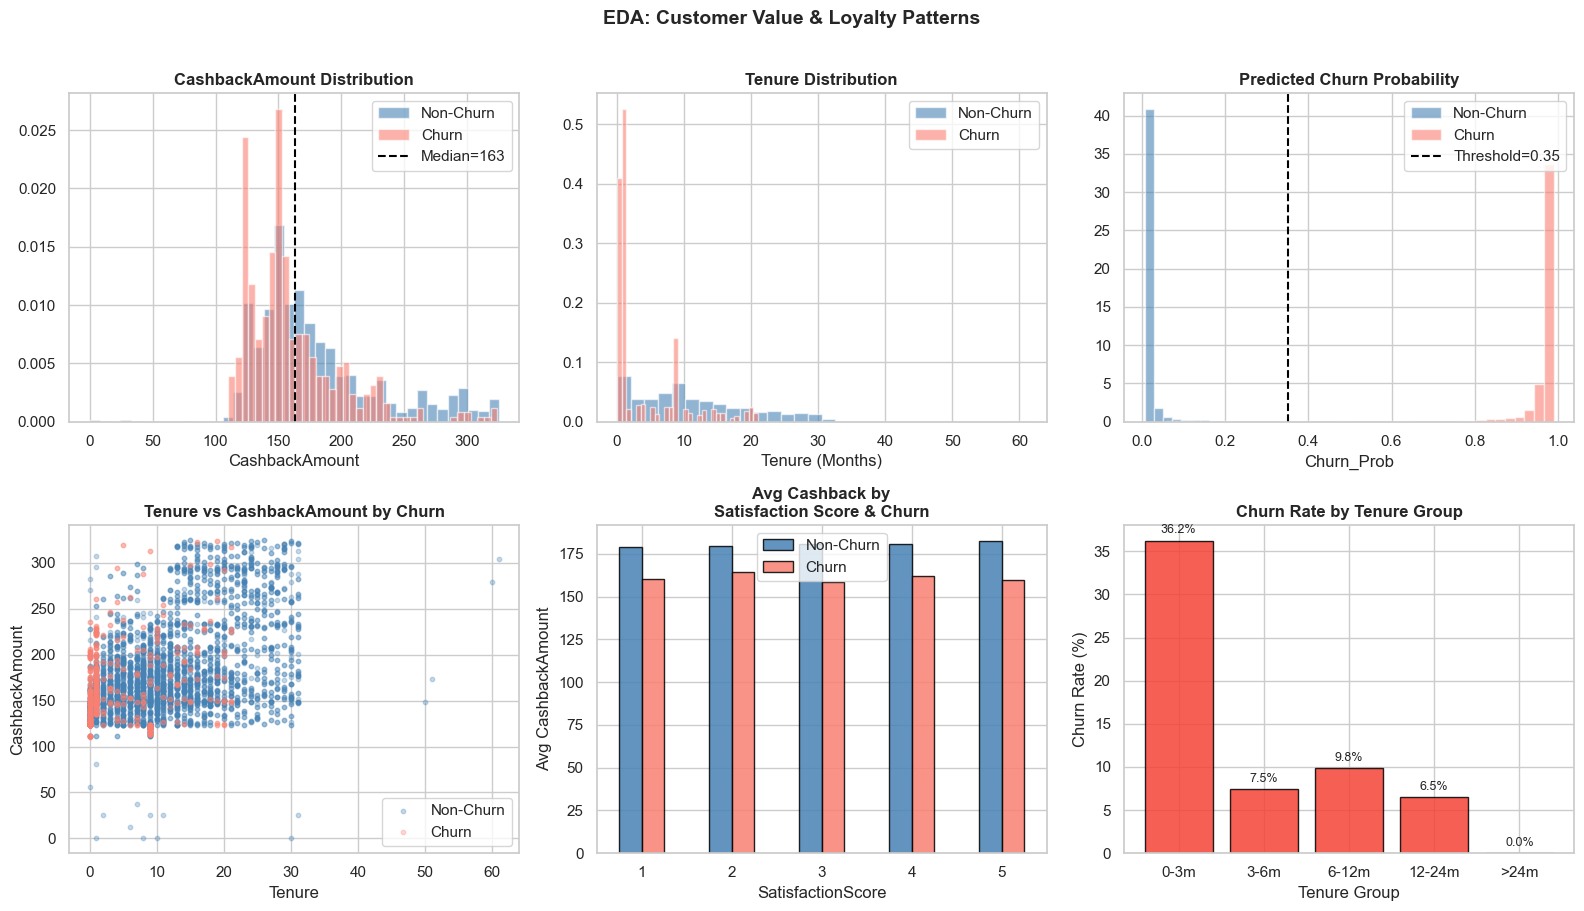

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. CashbackAmount distribution by Churn
for val, label, color in [(0,'Non-Churn','steelblue'),(1,'Churn','salmon')]:
    sub = df[df['Churn']==val]['CashbackAmount']
    axes[0,0].hist(sub, bins=40, alpha=0.6, label=label, color=color, density=True)
axes[0,0].axvline(df['CashbackAmount'].median(), color='black', linestyle='--', lw=1.5,
                   label=f'Median={df["CashbackAmount"].median():.0f}')
axes[0,0].set_title('CashbackAmount Distribution', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('CashbackAmount'); axes[0,0].legend()

# 2. Tenure distribution by Churn
for val, label, color in [(0,'Non-Churn','steelblue'),(1,'Churn','salmon')]:
    sub = df[df['Churn']==val]['Tenure']
    axes[0,1].hist(sub, bins=30, alpha=0.6, label=label, color=color, density=True)
axes[0,1].set_title('Tenure Distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Tenure (Months)'); axes[0,1].legend()

# 3. Churn_Prob distribution
axes[0,2].hist(df[df['Churn']==0]['Churn_Prob'], bins=40, alpha=0.6,
               color='steelblue', label='Non-Churn', density=True)
axes[0,2].hist(df[df['Churn']==1]['Churn_Prob'], bins=40, alpha=0.6,
               color='salmon', label='Churn', density=True)
axes[0,2].axvline(0.35, color='black', linestyle='--', lw=1.5, label='Threshold=0.35')
axes[0,2].set_title('Predicted Churn Probability', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Churn_Prob'); axes[0,2].legend()

# 4. Cashback vs Tenure scatter colored by Churn
colors_map = {0: 'steelblue', 1: 'salmon'}
for val, label in [(0,'Non-Churn'),(1,'Churn')]:
    sub = df[df['Churn']==val]
    axes[1,0].scatter(sub['Tenure'], sub['CashbackAmount'],
                      alpha=0.3, s=10, color=colors_map[val], label=label)
axes[1,0].set_xlabel('Tenure'); axes[1,0].set_ylabel('CashbackAmount')
axes[1,0].set_title('Tenure vs CashbackAmount by Churn', fontsize=12, fontweight='bold')
axes[1,0].legend()

# 5. Avg CashbackAmount by Churn + SatisfactionScore
grp = df.groupby(['SatisfactionScore','Churn'])['CashbackAmount'].mean().unstack()
grp.columns = ['Non-Churn','Churn']
grp.plot(kind='bar', ax=axes[1,1], color=['steelblue','salmon'],
         edgecolor='black', alpha=0.85)
axes[1,1].set_title('Avg Cashback by\nSatisfaction Score & Churn', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('SatisfactionScore'); axes[1,1].set_ylabel('Avg CashbackAmount')
axes[1,1].tick_params(axis='x', rotation=0)

# 6. Churn rate by Tenure bucket
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=[0,3,6,12,24,100],
                              labels=['0-3m','3-6m','6-12m','12-24m','>24m'])
churn_by_tenure = df.groupby('Tenure_Group')['Churn'].mean() * 100
bars = axes[1,2].bar(churn_by_tenure.index, churn_by_tenure.values,
                      color='#F44336', edgecolor='black', alpha=0.85)
for bar in bars:
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
axes[1,2].set_title('Churn Rate by Tenure Group', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Tenure Group'); axes[1,2].set_ylabel('Churn Rate (%)')

plt.suptitle('EDA: Customer Value & Loyalty Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

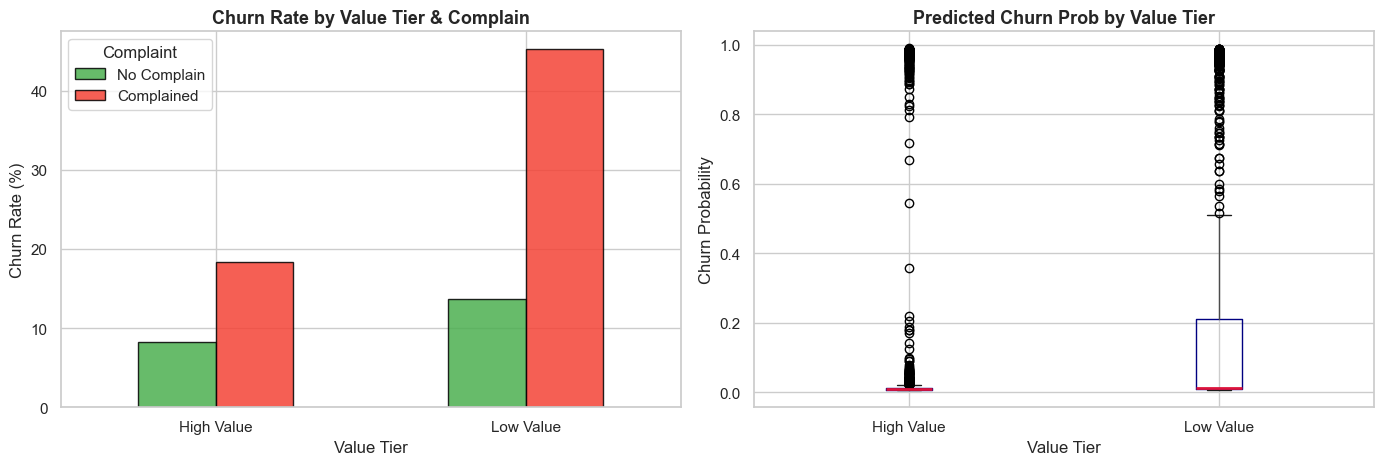

EDA Summary:
            Churn  Churn_Prob  Tenure  CashbackAmount
Value_Tier                                           
High Value  0.111       0.116  12.773         212.267
Low Value   0.227       0.244   7.427         141.268


In [17]:
# Churn rate by Complain + Value tier
VALUE_MEDIAN = df['CashbackAmount'].median()
df['Value_Tier'] = np.where(df['CashbackAmount'] >= VALUE_MEDIAN, 'High Value', 'Low Value')

pivot = df.groupby(['Value_Tier','Complain'])['Churn'].mean().unstack() * 100
pivot.columns = ['No Complain','Complained']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot.plot(kind='bar', ax=axes[0], color=['#4CAF50','#F44336'],
           edgecolor='black', alpha=0.85)
axes[0].set_title('Churn Rate by Value Tier & Complain', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Value Tier'); axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Complaint')

# Box plot: Churn_Prob by Value Tier
df.boxplot(column='Churn_Prob', by='Value_Tier', ax=axes[1],
           boxprops=dict(color='navy'), medianprops=dict(color='crimson', lw=2))
axes[1].set_title('Predicted Churn Prob by Value Tier', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Value Tier'); axes[1].set_ylabel('Churn Probability')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('EDA Summary:')
print(df.groupby('Value_Tier')[['Churn','Churn_Prob','Tenure','CashbackAmount']]
      .agg({'Churn':'mean','Churn_Prob':'mean','Tenure':'mean','CashbackAmount':'mean'})
      .round(3))

## 3. Value-Risk Quadrant

In [18]:
CHURN_THRESHOLD = 0.35

# ใช้ label ที่ไม่มี \n เพื่อให้ CSV export ถูกต้อง
quad_labels = {
    'PROTECT (VIP Loyalty)'       : '#2196F3',
    'RESCUE (Win-back + Loyalty)' : '#F44336',
    'MAINTAIN (Basic Perks)'      : '#4CAF50',
    'LET GO (ไม่ลงทุน)'           : '#9E9E9E',
}
quad_colors = quad_labels  # alias for plotting

def assign_quadrant(row):
    high_risk  = row['Churn_Prob']     >= CHURN_THRESHOLD
    high_value = row['CashbackAmount'] >= VALUE_MEDIAN
    if     high_value and not high_risk: return 'PROTECT (VIP Loyalty)'
    elif   high_value and     high_risk: return 'RESCUE (Win-back + Loyalty)'
    elif not high_value and not high_risk: return 'MAINTAIN (Basic Perks)'
    else:                                  return 'LET GO (ไม่ลงทุน)'

df['Quadrant'] = df.apply(assign_quadrant, axis=1)

quad_summary = df.groupby('Quadrant').agg(
    Count       =('CustomerID',    'count'),
    Avg_Prob    =('Churn_Prob',    'mean'),
    Avg_Cash    =('CashbackAmount','mean'),
    Avg_Tenure  =('Tenure',        'mean'),
    Actual_Churn=('Churn',         'mean'),
).round(3).sort_values('Avg_Prob', ascending=False)


print(f'Churn threshold : {CHURN_THRESHOLD}  |  Value median: {VALUE_MEDIAN:.1f}\n')display(quad_summary)

SyntaxError: invalid syntax (4233428882.py, line 31)

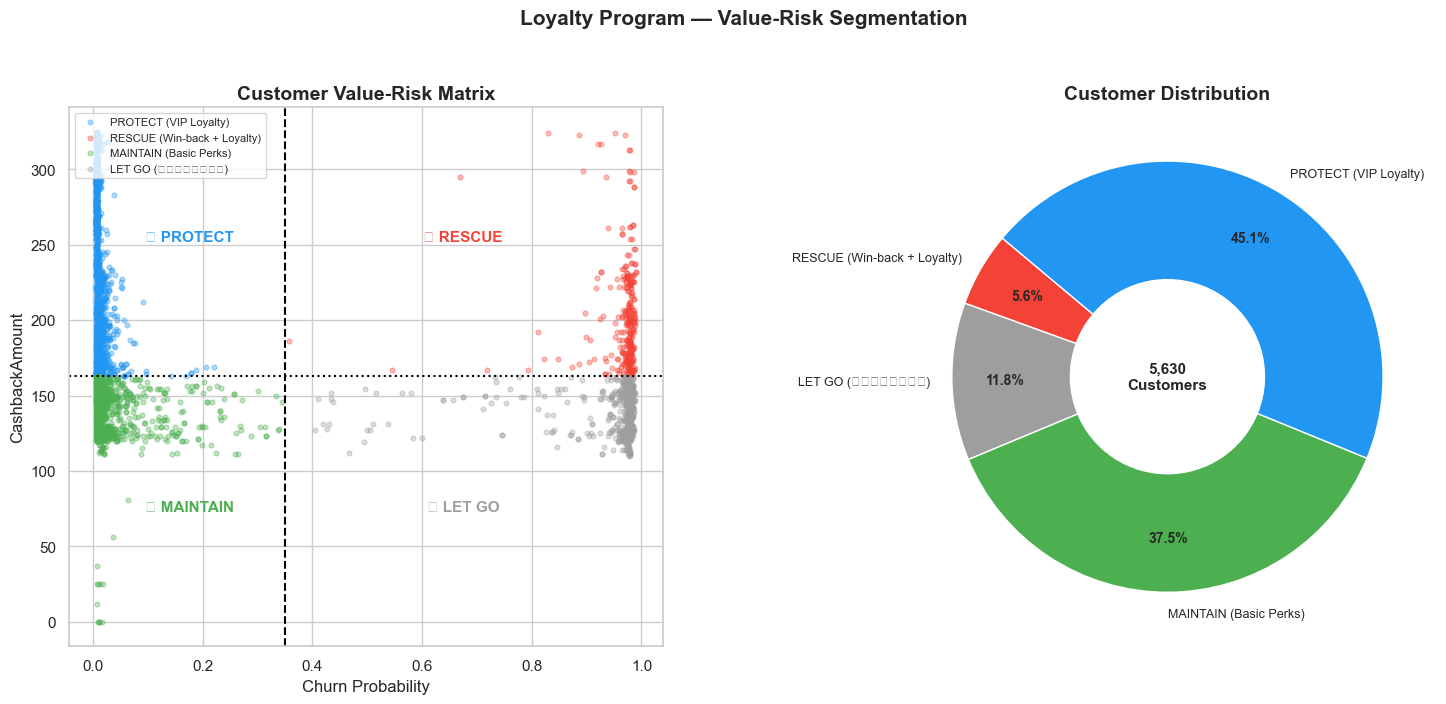

In [ ]:
fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
for quad, color in quad_colors.items():
    sub = df[df['Quadrant'] == quad]
    ax1.scatter(sub['Churn_Prob'], sub['CashbackAmount'],
                alpha=0.35, s=12, color=color, label=quad)
ax1.axvline(CHURN_THRESHOLD, color='black', linestyle='--', lw=1.5)
ax1.axhline(VALUE_MEDIAN, color='black', linestyle=':', lw=1.5)
ax1.text(CHURN_THRESHOLD/2,         VALUE_MEDIAN*1.55, '★ PROTECT',
         ha='center', fontsize=11, color='#2196F3', fontweight='bold')
ax1.text((CHURN_THRESHOLD+1)/2,     VALUE_MEDIAN*1.55, '⚠ RESCUE',
         ha='center', fontsize=11, color='#F44336', fontweight='bold')
ax1.text(CHURN_THRESHOLD/2,         VALUE_MEDIAN*0.45, '✓ MAINTAIN',
         ha='center', fontsize=11, color='#4CAF50', fontweight='bold')
ax1.text((CHURN_THRESHOLD+1)/2,     VALUE_MEDIAN*0.45, '✗ LET GO',
         ha='center', fontsize=11, color='#9E9E9E', fontweight='bold')
ax1.set_xlabel('Churn Probability'); ax1.set_ylabel('CashbackAmount')
ax1.set_title('Customer Value-Risk Matrix', fontsize=14, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')

ax2 = fig.add_subplot(gs[1])
counts = quad_summary['Count']
wedges, texts, autotexts = ax2.pie(
    counts, labels=counts.index.tolist(),
    colors=[quad_colors[q] for q in counts.index],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(width=0.55), pctdistance=0.75, textprops={'fontsize': 9})
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax2.text(0, 0, f'{counts.sum():,}\nCustomers',
         ha='center', va='center', fontsize=11, fontweight='bold')
ax2.set_title('Customer Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Loyalty Program — Value-Risk Segmentation', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('outputs/figures/value_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Priority Retention List — กลุ่ม RESCUE

In [ ]:
rescue_df = (
    df[df['Quadrant'] == 'RESCUE (Win-back + Loyalty)']
    [['CustomerID','Churn_Prob','CashbackAmount','Tenure',
      'OrderCount','Complain','SatisfactionScore','Churn']]
    .sort_values('Churn_Prob', ascending=False)
    .reset_index(drop=True)
)
rescue_df.index += 1
rescue_df.index.name = 'Priority'

print(f'RESCUE List: {len(rescue_df):,} customers (High Value + High Churn Risk)')
print(f'Avg Churn Prob   : {rescue_df["Churn_Prob"].mean():.3f}')
print(f'Avg Cashback     : {rescue_df["CashbackAmount"].mean():.1f}')
print(f'Actually Churned : {rescue_df["Churn"].mean():.1%}\n')
print('Top 20 Priority Customers:')
display(rescue_df.head(20).style
        .background_gradient(subset=['Churn_Prob'],     cmap='Reds')
        .background_gradient(subset=['CashbackAmount'], cmap='Greens')
        .format({'Churn_Prob':'{:.3f}','CashbackAmount':'{:.0f}',
                 'Tenure':'{:.1f}','OrderCount':'{:.1f}'}))

RESCUE List: 314 customers (High Value + High Churn Risk)
Avg Churn Prob   : 0.964
Avg Cashback     : 202.3
Actually Churned : 99.4%

Top 20 Priority Customers:


,CustomerID,Churn_Prob,CashbackAmount,Tenure,OrderCount,Complain,SatisfactionScore,Churn
Priority,,,,,,,,
1,52840,0.990,232,15.0,2.0,0,2,1
2,54297,0.989,232,15.0,2.0,0,1,1
3,53298,0.989,202,13.0,8.0,0,2,1
4,50015,0.988,196,9.0,4.0,0,2,1
5,50842,0.988,200,20.0,5.0,1,5,1
6,53504,0.988,247,3.0,2.0,0,2,1
7,54024,0.988,198,10.0,2.0,0,4,1
8,50404,0.988,168,13.0,1.0,1,3,1
9,52321,0.988,237,18.0,2.0,1,3,1


## 5. Loyalty Program Design

| Quadrant | กลยุทธ์ | ตัวอย่าง Offer |
|---|---|---|
| ★ **PROTECT** | รักษาและเสริมความภักดี | VIP tier, early access, free shipping |
| ⚠ **RESCUE** | Win-back อย่างเร่งด่วน | Personal outreach, ลด 20-30%, dedicated service |
| ✓ **MAINTAIN** | Nurture ให้เติบโต | Basic point system, birthday coupon |
| ✗ **LET GO** | หยุด marketing | ลบออกจาก campaign list |


In [ ]:
rescue_df.to_csv('outputs/csv/rescue_priority_list.csv')
print('✓ Saved outputs/csv/rescue_priority_list.csv')
print(f'  {len(rescue_df):,} customers to prioritize for loyalty program')

✓ Saved rescue_priority_list.csv
  314 customers to prioritize for loyalty program
